# What is my task?

Today, a healthcare company came to us and asked us to make a model of artificial intelligence to help doctors predict people survival status. They gave me a dataset, but the problem is that i lost the link of dataset and only have the *.csv* file.

# What do we have?

I have a file wich named `cancer.csv` with these features:

* **rownames**: This column seems to be a unique identifier for each sample or row in the dataset.

* **inst**: This likely represents an institution code, possibly indicating which hospital or research center the patient data came from.

* **time**: This variable probably denotes the survival time or follow-up period for each patient, most likely measured in days.

* **status**: This is a crucial variable, indicating the patient's survival status. Typically, a value of 1 might represent death, and 2 might represent being alive at the end of the follow-up period.

* **age**: The age of the patient in years.

* **sex**: This indicates the patient's gender. Based on the preview, '1' could represent male and '2' could represent female, but this would need confirmation from the data's documentation or further analysis.

* **ph.ecog**: This is the Eastern Cooperative Oncology Group (ECOG) performance status score, as assessed by a physician. It's a common scale to measure how a patient's disease is affecting their daily living abilities.

* **ph.karno**: This is the Karnofsky performance score, again assessed by a physician. This scale also measures a patient's ability to perform activities of daily living.

* **pat.karno**: Similar to `ph.karno`, but this score is likely provided by the patient themselves, reflecting their own perception of their functional status.

* **meal.cal**: This column probably represents the caloric intake from meals for each patient.

* **wt.loss**: This indicates the patient's weight loss, likely measured over a specific period, such as the last 6 months.

I think we have to predict the value of **status**.

# Evaluation metrics

Our task is a classification problem, So I'll use classification metrics for it.

# Code part

## Import needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import helpers

SEED = 231

/home/sir-unchained/Desktop/labratory/ml-trains/ml-ds-repo/Cancer Detectoin/helpers.py:11: UserWarning: tensorflow is not installed. Some helpers will not work.
  warnings.warn(f"{module_name} is not installed. Some helpers will not work.")
/home/sir-unchained/Desktop/labratory/ml-trains/ml-ds-repo/Cancer Detectoin/helpers.py:11: UserWarning: albumentations is not installed. Some helpers will not work.
  warnings.warn(f"{module_name} is not installed. Some helpers will not work.")


## Dataset part

### Analyze data

In [2]:
df = pd.read_csv("./cancer.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   rownames   228 non-null    int64  
 1   inst       227 non-null    float64
 2   time       228 non-null    int64  
 3   status     228 non-null    int64  
 4   age        228 non-null    int64  
 5   sex        228 non-null    int64  
 6   ph.ecog    227 non-null    float64
 7   ph.karno   227 non-null    float64
 8   pat.karno  225 non-null    float64
 9   meal.cal   181 non-null    float64
 10  wt.loss    214 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 19.7 KB


In [4]:
df.sample(5)

,rownames,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
56,57,5.0,5,2,65,2,0.0,100.0,80.0,338.0,5.0
84,85,16.0,806,1,44,1,1.0,80.0,80.0,1025.0,1.0
1,2,3.0,455,2,68,1,0.0,90.0,90.0,1225.0,15.0
53,54,1.0,246,2,58,1,0.0,100.0,90.0,1175.0,7.0
200,201,15.0,79,2,64,2,1.0,90.0,90.0,488.0,37.0


Ok so we have **228** rows with **11** features.

It seems like we have some missing values too. 

But the good part is that all the values are **int66** and **float64** so we dont need to use `labelEncoder`.

The value of feature `time` should be **float64**, `ph.ecog` is a score feature *from 0 to 3* which means it shall be **int64** and `age` can be also **float64**. I will not fix it here.

Now let's check is our data balanced or not:

<Axes: >

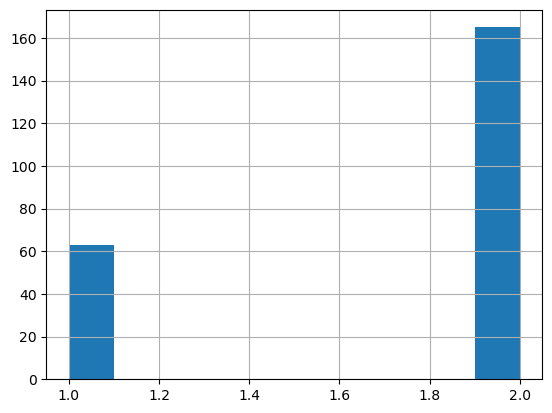

In [5]:
df["status"].hist()

And dataset is not balanced, people who get value **2** and people who die get value **1**.

### Analyze numerical features

In [6]:
df_num = df.select_dtypes(include=["float64"])

In [7]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
inst,227.0,11.088106,8.303491,1.0,3.0,11.0,16.00,33.0
ph.ecog,227.0,0.951542,0.717872,0.0,0.0,1.0,1.00,3.0
ph.karno,227.0,81.938326,12.327955,50.0,75.0,80.0,90.00,100.0
pat.karno,225.0,79.955556,14.623177,30.0,70.0,80.0,90.00,100.0
meal.cal,181.0,928.779006,402.174707,96.0,635.0,975.0,1150.00,2600.0
wt.loss,214.0,9.831776,13.139902,-24.0,0.0,7.0,15.75,68.0


I can see some outliers in `time`and `meal.cal`. We can have better understanding with visualizing:

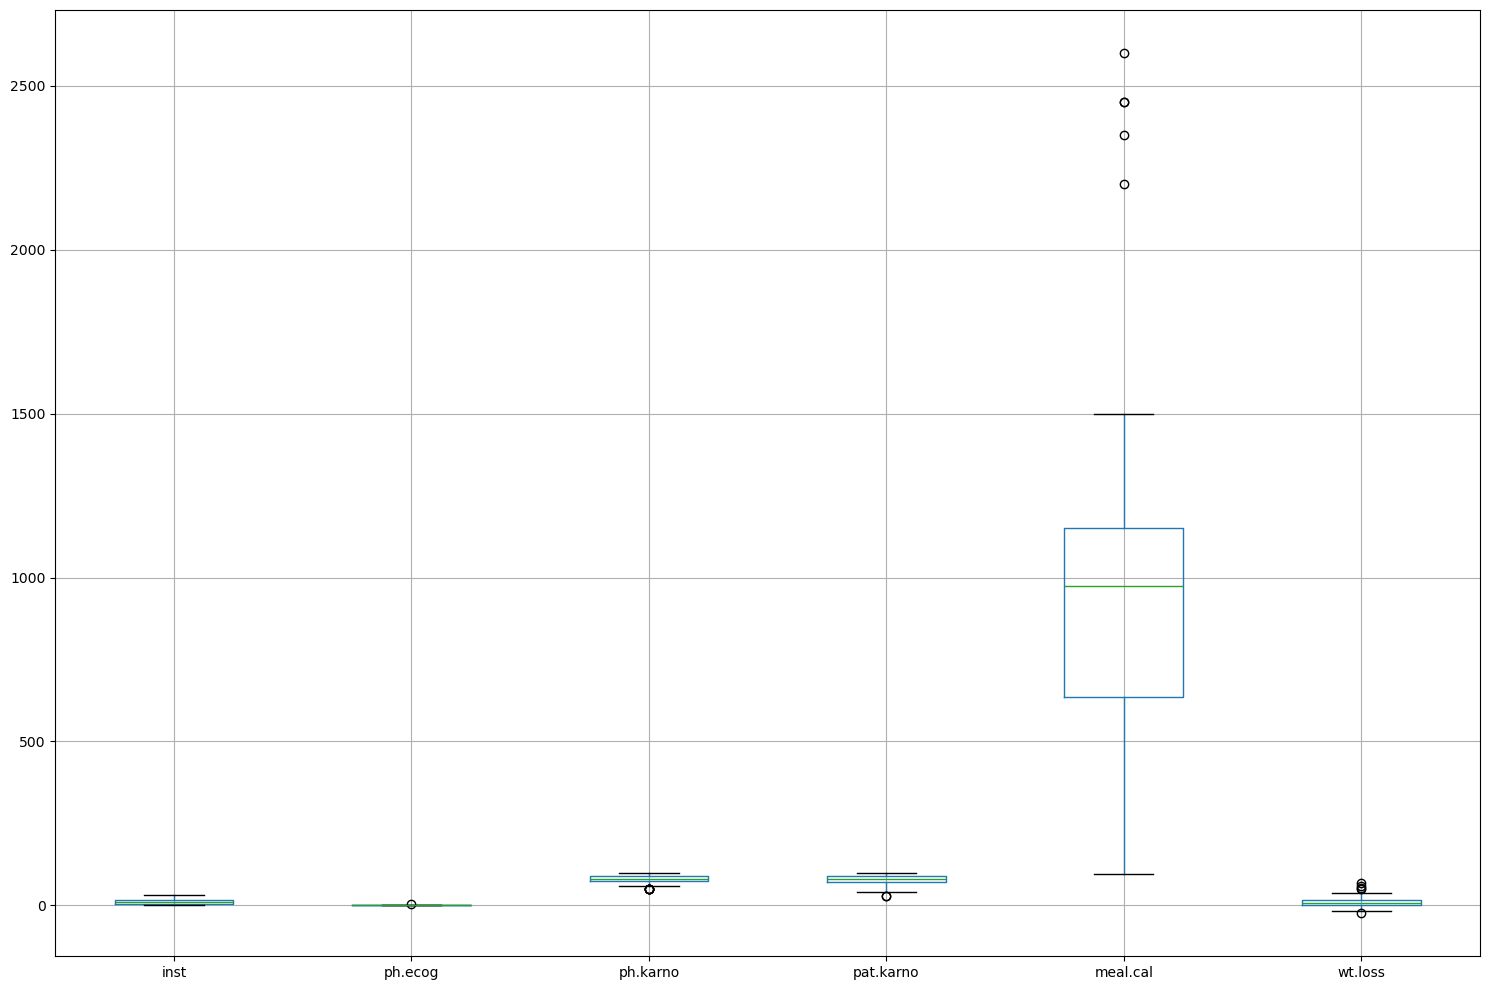

In [8]:
df_num.boxplot(figsize=(15, 10))
plt.tight_layout()
plt.show()

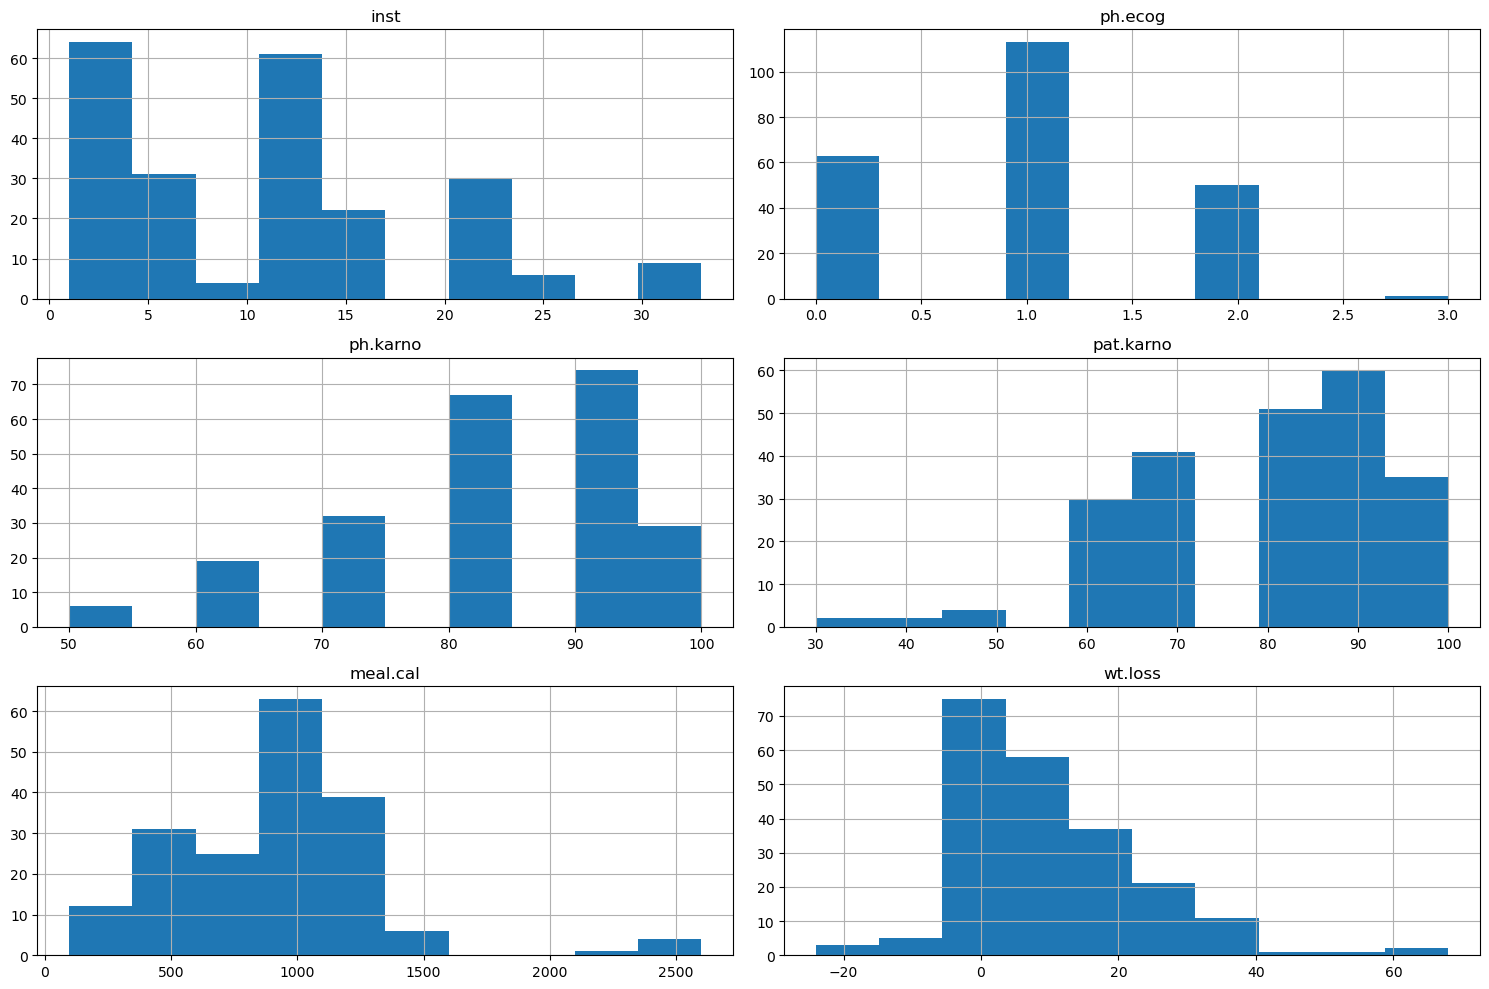

In [9]:
df_num.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

### Analyze categorical features

In [10]:
df_cat = df.select_dtypes(include="int64")

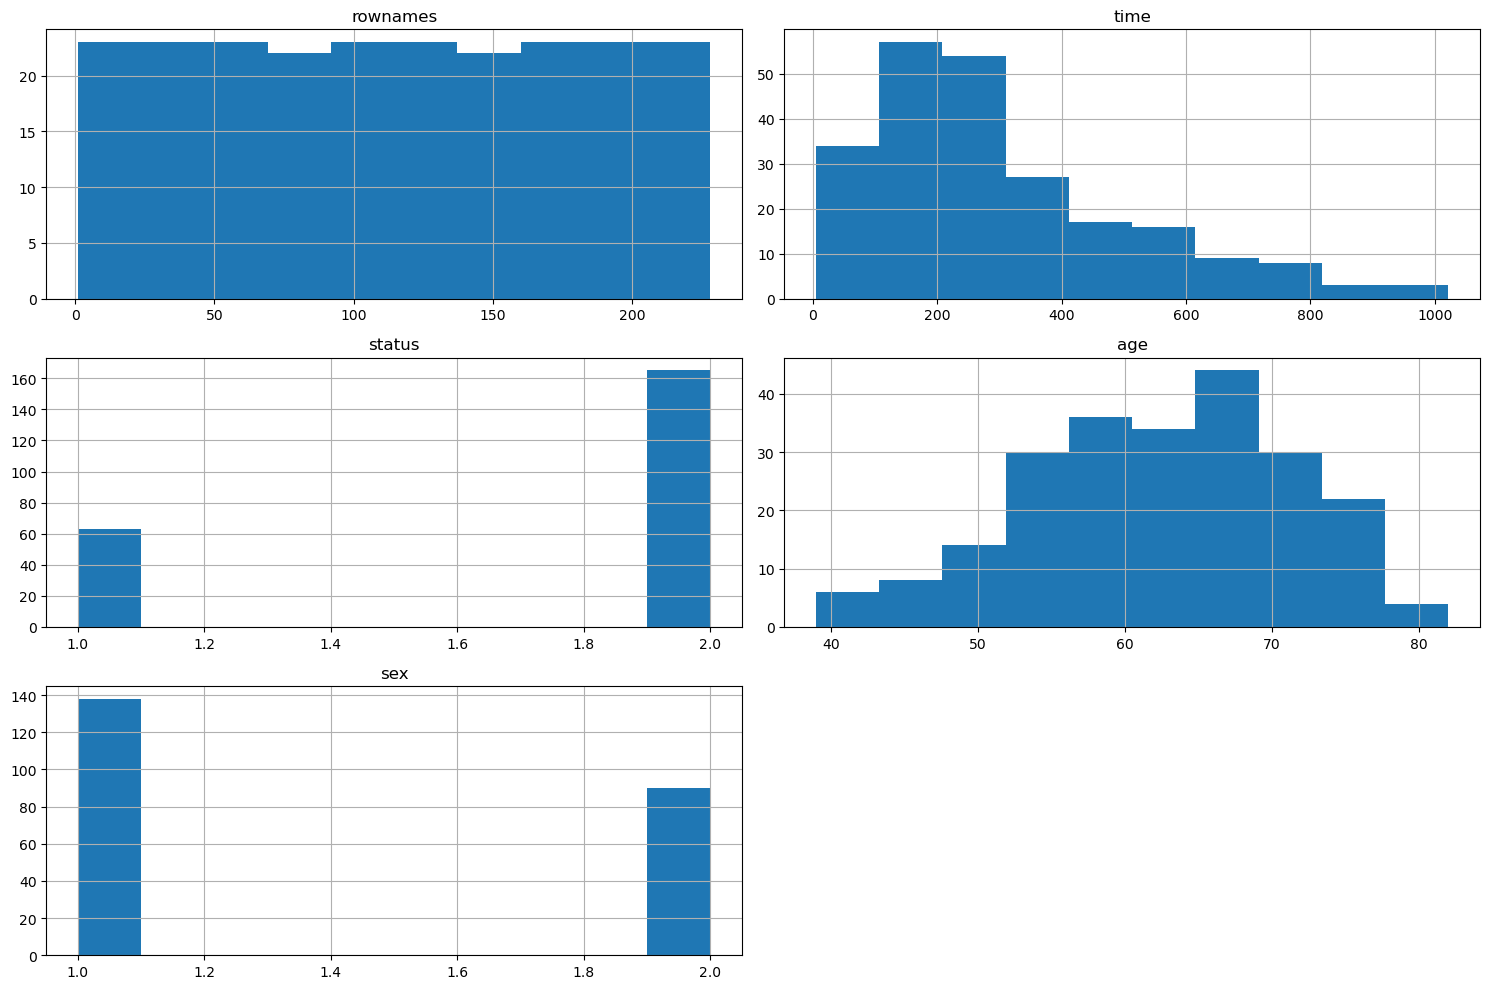

In [11]:
df_cat.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

So we have more male than female. But as you remember i did not convert all categorical features into **int64**.

In [12]:
df["ph.ecog"].unique()

array([ 1.,  0.,  2., nan,  3.])

### Analyze correlation

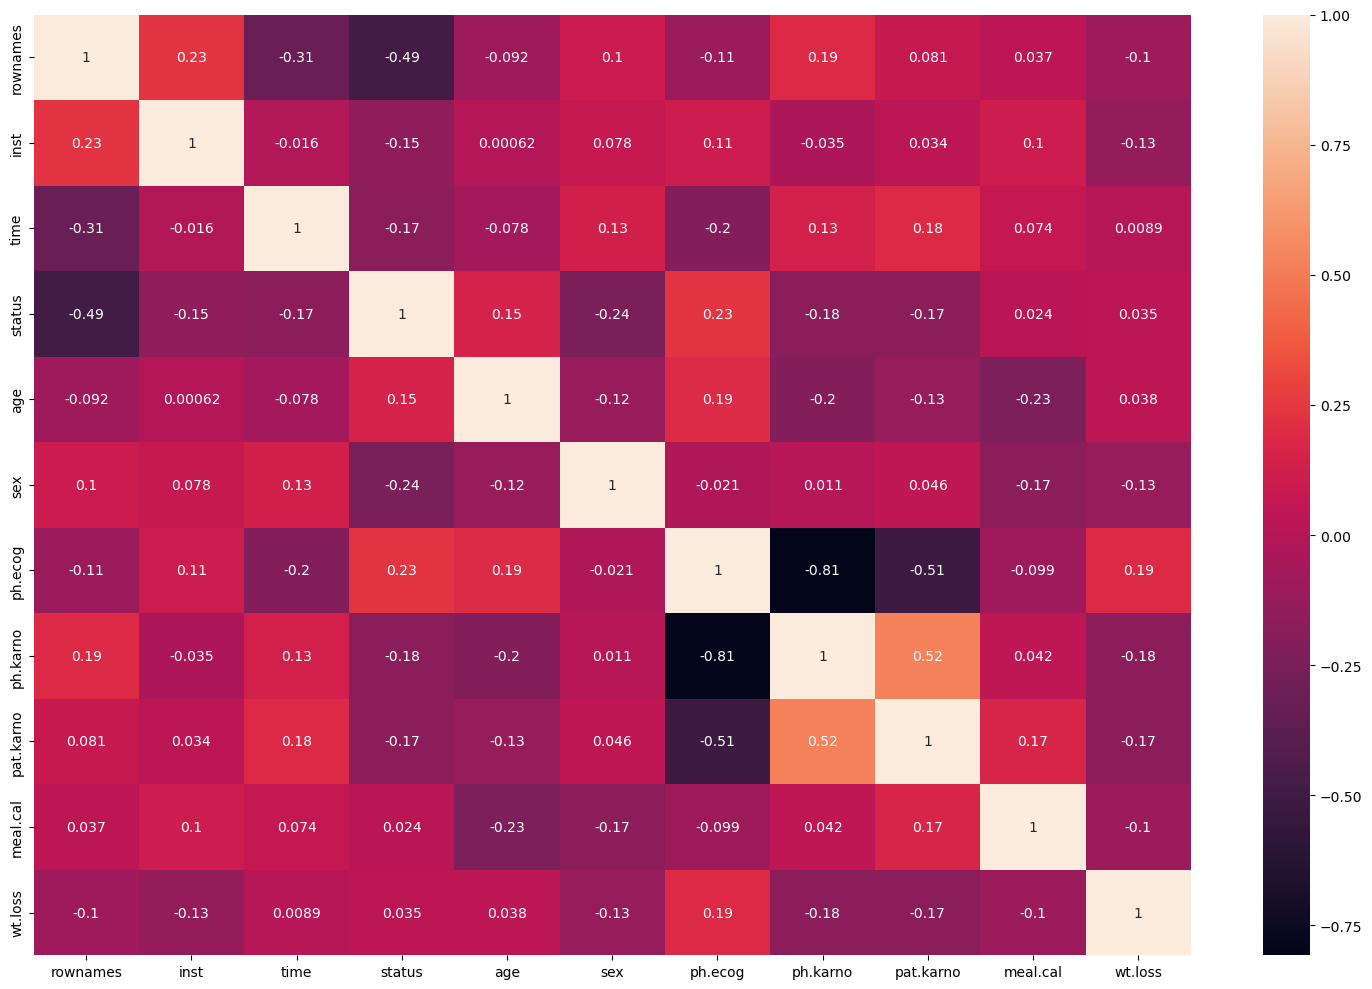

In [13]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True)
plt.tight_layout()
plt.show()

We have strong correlation between `ph.ecog` and `ph.karno`, We may need to remove one.

## Feature Engeeniering + Preprocess

### Remove unneeded features

We don't need features `rownames` and `inst`:

In [14]:
df = df.drop(columns=["rownames"])
df = df.drop(columns=["inst"])

### Change target feature values

Our target feature is `status` which has value 2 (dead) and 1 (alive), I'll change it to 1 and 0.

In [15]:
df["status"].head()

0    2
1    2
2    1
3    2
4    2
Name: status, dtype: int64

In [16]:
le = LabelEncoder()
df["status"] = le.fit_transform(df["status"])

In [17]:
df["status"].head()

0    1
1    1
2    0
3    1
4    1
Name: status, dtype: int64

### Handel missing values

#### Categorical features

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       228 non-null    int64  
 1   status     228 non-null    int64  
 2   age        228 non-null    int64  
 3   sex        228 non-null    int64  
 4   ph.ecog    227 non-null    float64
 5   ph.karno   227 non-null    float64
 6   pat.karno  225 non-null    float64
 7   meal.cal   181 non-null    float64
 8   wt.loss    214 non-null    float64
dtypes: float64(5), int64(4)
memory usage: 16.2 KB


Feature `ph.ecog` has only one missed value same as `ph.karno`. They are also categorical features so I fill them using `median` of the feature:

In [19]:
df["ph.ecog"] = df["ph.ecog"].fillna(value=df["ph.ecog"].median())
df["ph.karno"] = df["ph.karno"].fillna(value=df["ph.karno"].median())

#### Numerical features

Let's check `df.info` again:

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       228 non-null    int64  
 1   status     228 non-null    int64  
 2   age        228 non-null    int64  
 3   sex        228 non-null    int64  
 4   ph.ecog    228 non-null    float64
 5   ph.karno   228 non-null    float64
 6   pat.karno  225 non-null    float64
 7   meal.cal   181 non-null    float64
 8   wt.loss    214 non-null    float64
dtypes: float64(5), int64(4)
memory usage: 16.2 KB


Feature `pat.karno` only has 1 missed value, feature `wt.loss` has 2 missed values. I want to fill these missed values with mean of the feature:

In [21]:
df["wt.loss"] = df["wt.loss"].fillna(value=df["wt.loss"].mean())
df["pat.karno"] = df["pat.karno"].fillna(value=df["pat.karno"].mean())

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       228 non-null    int64  
 1   status     228 non-null    int64  
 2   age        228 non-null    int64  
 3   sex        228 non-null    int64  
 4   ph.ecog    228 non-null    float64
 5   ph.karno   228 non-null    float64
 6   pat.karno  228 non-null    float64
 7   meal.cal   181 non-null    float64
 8   wt.loss    228 non-null    float64
dtypes: float64(5), int64(4)
memory usage: 16.2 KB


Feature `meal.cal` has a lot of missed values, this time I'll use `KNN-imputer` to fill it.

In [23]:
knn = KNNImputer()

df = pd.DataFrame(
    data=knn.fit_transform(df.values, df["status"].values), columns=df.columns
)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       228 non-null    float64
 1   status     228 non-null    float64
 2   age        228 non-null    float64
 3   sex        228 non-null    float64
 4   ph.ecog    228 non-null    float64
 5   ph.karno   228 non-null    float64
 6   pat.karno  228 non-null    float64
 7   meal.cal   228 non-null    float64
 8   wt.loss    228 non-null    float64
dtypes: float64(9)
memory usage: 16.2 KB


array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'status'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'ph.ecog'}>,
        <Axes: title={'center': 'ph.karno'}>],
       [<Axes: title={'center': 'pat.karno'}>,
        <Axes: title={'center': 'meal.cal'}>,
        <Axes: title={'center': 'wt.loss'}>]], dtype=object)

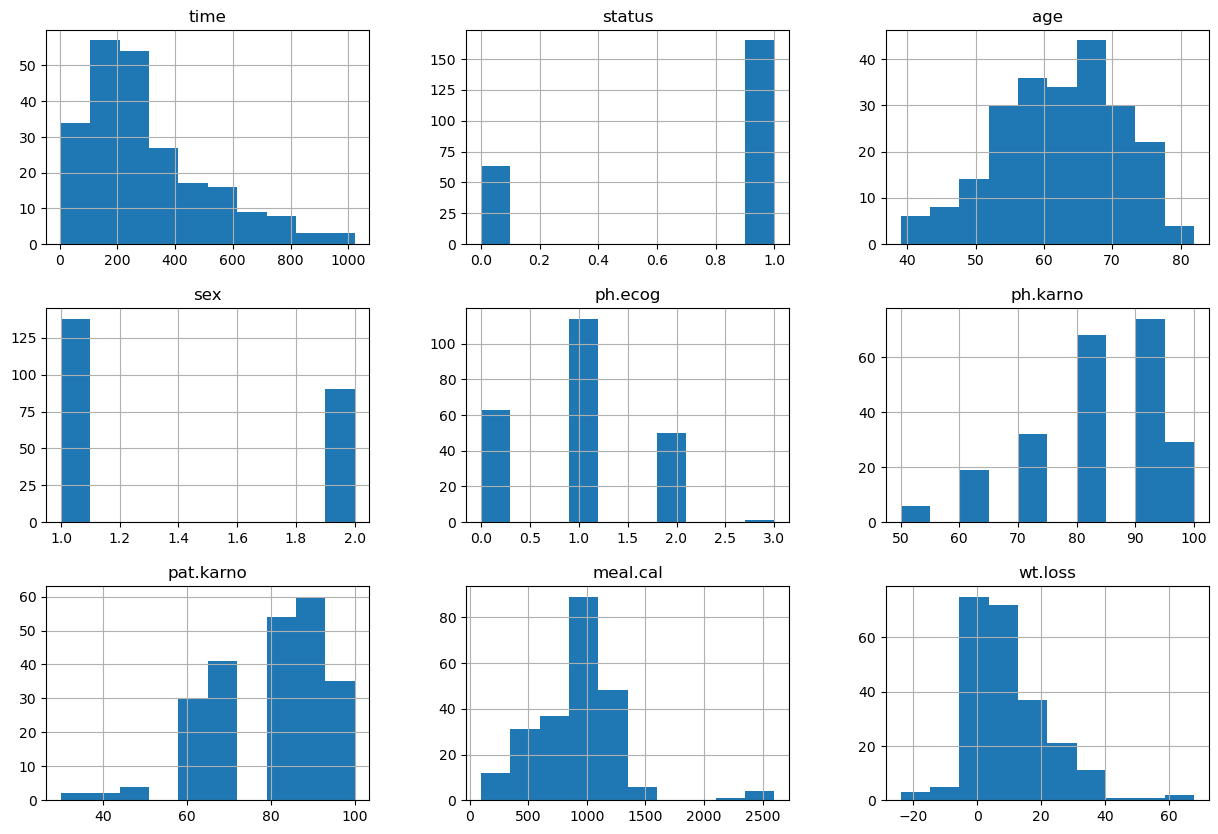

In [25]:
df.hist(figsize=(15, 10))

Ok, let's continue.

### Convert dtypes

The value of feature `time` should be **float64**, `ph.ecog` is a score feature *from 0 to 3* which means it shall be **int64** and `age` can be also **float64**. 

I'm going to fix it now:

In [26]:
df["time"] = df["time"].astype("float64")
df["ph.ecog"] = df["ph.ecog"].astype("float64")
df["age"] = df["age"].astype("float64")

### Hadel imbalanced data (SMOTE)

In [27]:
smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(
    X=df.drop(columns=["status"]), y=df["status"]
)

### Handel outliers

As you remember, we had some outliers. 

The main problem is *We don't have much data!*, so i'll not use **IQR Method** or **Z-Score Method**.

I can use robust scaler here, it can hendel outlier treatment:

In [28]:
rb = RobustScaler()
X_resampled = rb.fit_transform(X_resampled)

### Train and test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, random_state=SEED, shuffle=True, test_size=0.30
)

## Model design

### SVM

In [44]:
svc = SVC(random_state=SEED, probability=True)

svc.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [45]:
y_hat = svc.predict(X_test)
svc_result = helpers.evaluate_classification_model(
    y_pred=y_hat, y_test=y_test, model_name="svc"
)

              precision    recall  f1-score   support

         0.0       0.69      0.87      0.77        46
         1.0       0.85      0.66      0.74        53

    accuracy                           0.76        99
   macro avg       0.77      0.76      0.76        99
weighted avg       0.78      0.76      0.76        99



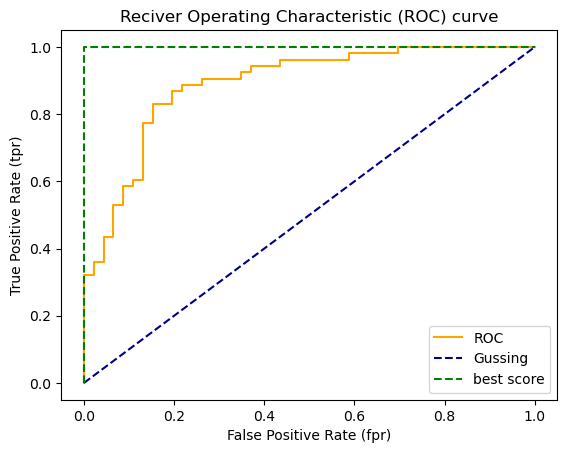

In [46]:
helpers.plot_roc_curve(svc, X_test, y_test)

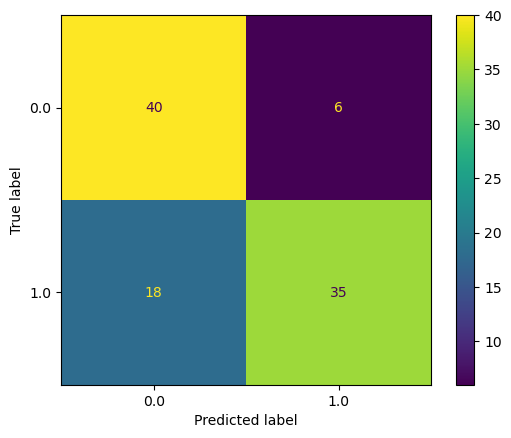

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_pred=y_hat, y_true=y_test)

#### SVM + GridSearch

In [ ]:
svc_with_gs = SVC(random_state=SEED, probability=True)


param_grid = {
    "C": [0.1, 1, 10, 20, 30, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1, 2, 3],
}

svc_with_gs = helpers.run_grid_search(
    svc_with_gs, param_grid, X_train, y_train, 5, "SVC"
)

Fitting 5 folds for each of 42 candidates, totalling 210 fits



--- Grid Search for `SVC` ---
Best Hyper Parameters: {'C': 10, 'gamma': 1}
Best Mean Log Loss (CV): 0.3479


In [53]:
y_hat = svc_with_gs.predict(X_test)
svc_with_gs_result = helpers.evaluate_classification_model(
    y_pred=y_hat, y_test=y_test, model_name="svc_with_gs"
)

              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88        46
         1.0       0.90      0.89      0.90        53

    accuracy                           0.89        99
   macro avg       0.89      0.89      0.89        99
weighted avg       0.89      0.89      0.89        99



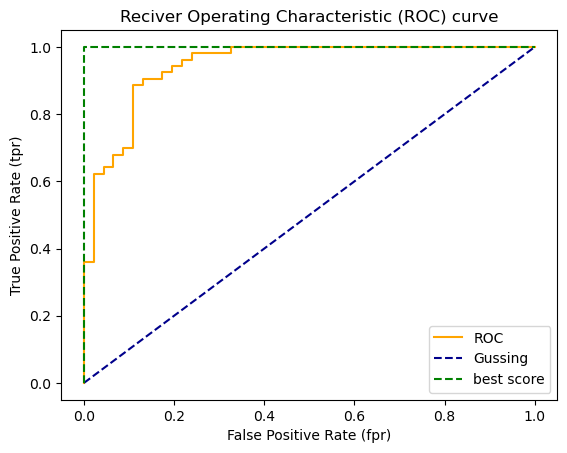

In [54]:
helpers.plot_roc_curve(svc_with_gs, X_test, y_test)

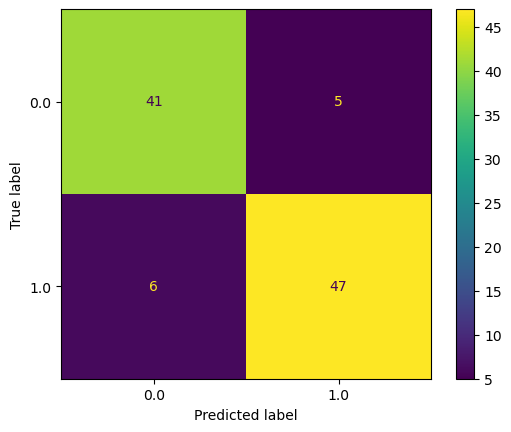

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_pred=y_hat, y_true=y_test)

### Logistic Regression

In [74]:
lr = LogisticRegression(random_state=SEED)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,231
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [75]:
y_hat = lr.predict(X_test)
lr_result = helpers.evaluate_classification_model(
    y_pred=y_hat, y_test=y_test, model_name="logistic regression"
)

              precision    recall  f1-score   support

         0.0       0.56      0.74      0.64        46
         1.0       0.68      0.49      0.57        53

    accuracy                           0.61        99
   macro avg       0.62      0.61      0.60        99
weighted avg       0.63      0.61      0.60        99



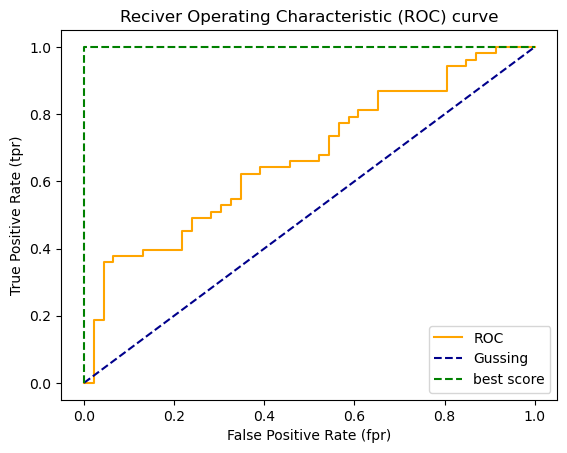

In [76]:
helpers.plot_roc_curve(lr, X_test, y_test)

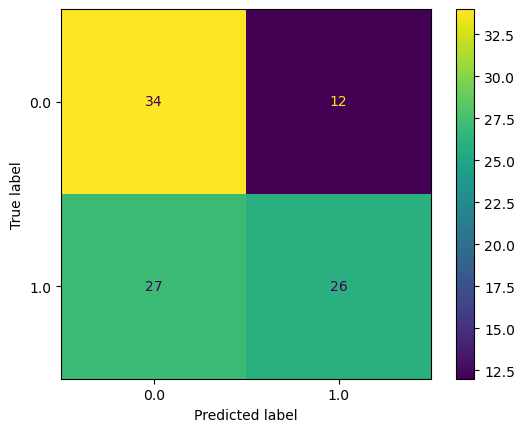

In [77]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_hat, y_true=y_test)

#### Logistic Regression + GridSearch

In [ ]:
lr_with_gs = LogisticRegression(random_state=SEED)

param_grid = {"C": [1, 2, 3, 10, 20, 30], "tol": [0.0002, 0.005, 0.05, 0.5, 1, 3, 10]}

lr_with_gs = helpers.run_grid_search(
    lr_with_gs, param_grid, X_train, y_train, 5, "logistic regression"
)

Fitting 5 folds for each of 42 candidates, totalling 210 fits

--- Grid Search for `logistic regression` ---
Best Hyper Parameters: {'C': 1, 'tol': 0.05}
Best Mean Log Loss (CV): 0.6103


In [79]:
y_hat = lr_with_gs.predict(X_test)
lr_with_gs_result = helpers.evaluate_classification_model(
    y_pred=y_hat, y_test=y_test, model_name="logistic regression"
)

              precision    recall  f1-score   support

         0.0       0.58      0.83      0.68        46
         1.0       0.76      0.47      0.58        53

    accuracy                           0.64        99
   macro avg       0.67      0.65      0.63        99
weighted avg       0.67      0.64      0.63        99



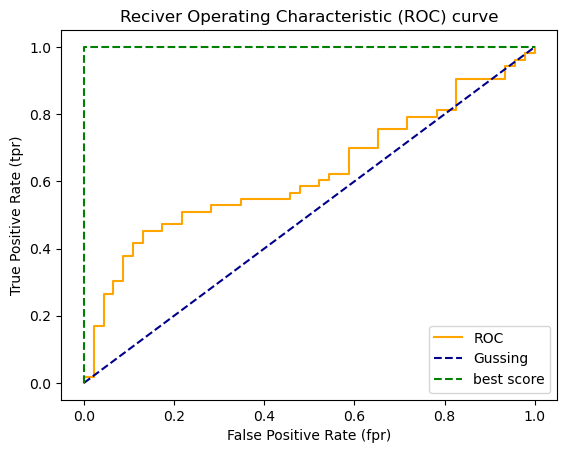

In [80]:
helpers.plot_roc_curve(lr_with_gs, X_test, y_test)

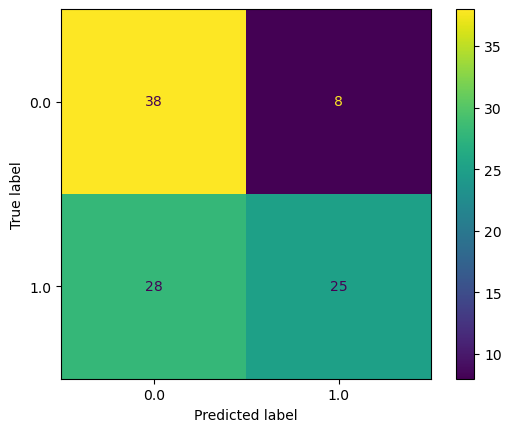

In [81]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_hat, y_true=y_test)

### Random Forest

In [87]:
rfc = RandomForestClassifier(random_state=SEED)
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
y_hat = rfc.predict(X_test)
rfc_result = helpers.evaluate_classification_model(
    y_pred=y_hat, y_test=y_test, model_name="random forest"
)

              precision    recall  f1-score   support

         0.0       0.81      0.85      0.83        46
         1.0       0.86      0.83      0.85        53

    accuracy                           0.84        99
   macro avg       0.84      0.84      0.84        99
weighted avg       0.84      0.84      0.84        99



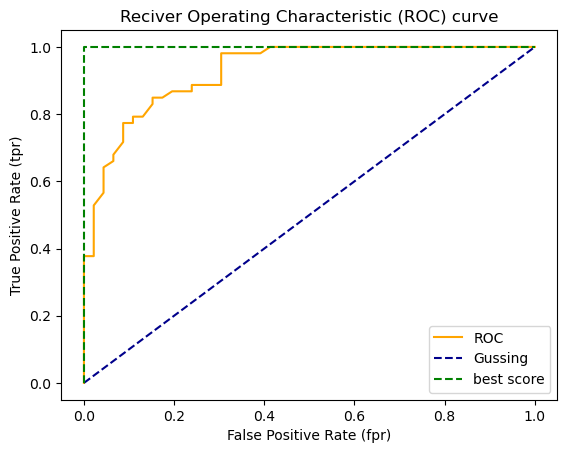

In [89]:
helpers.plot_roc_curve(rfc, X_test, y_test)

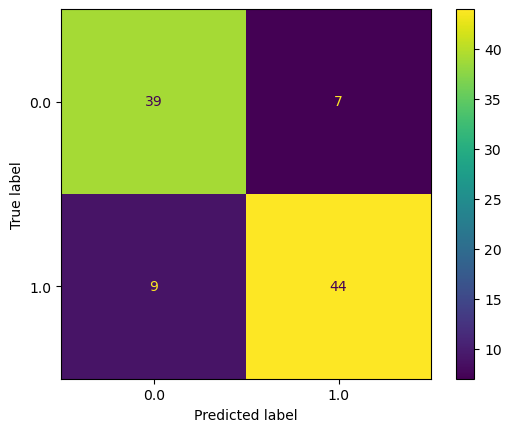

In [90]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_hat, y_true=y_test)

#### Random Forest + GridSearch

In [ ]:
rfc_with_gs = RandomForestClassifier(random_state=SEED)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2", None],
}

rfc_with_gs = helpers.run_grid_search(
    rfc_with_gs, param_grid, X_train, y_train, 5, "random forest"
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

--- Grid Search for `random forest` ---
Best Hyper Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Mean Log Loss (CV): 0.4282


In [84]:
y_hat = rfc_with_gs.predict(X_test)
rfc_with_gs_result = helpers.evaluate_classification_model(
    y_pred=y_hat, y_test=y_test, model_name="random forest"
)

              precision    recall  f1-score   support

         0.0       0.84      0.80      0.82        46
         1.0       0.84      0.87      0.85        53

    accuracy                           0.84        99
   macro avg       0.84      0.84      0.84        99
weighted avg       0.84      0.84      0.84        99



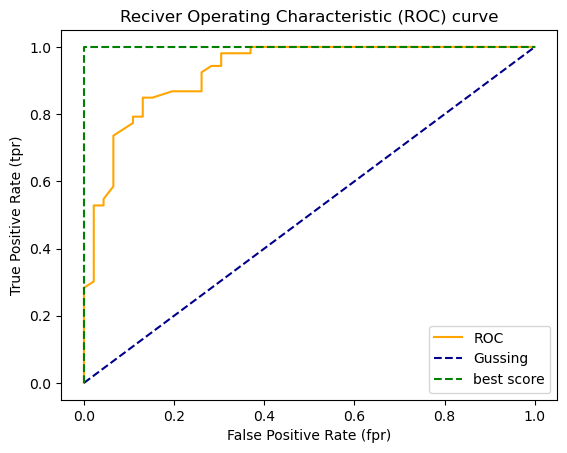

In [85]:
helpers.plot_roc_curve(rfc_with_gs, X_test, y_test)

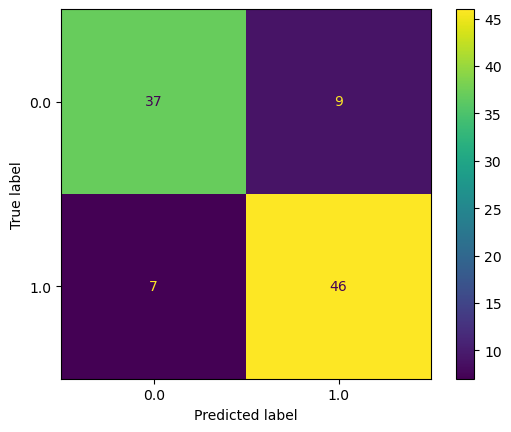

In [86]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_hat, y_true=y_test)

### KNN classifier

In [91]:
knnc = KNeighborsClassifier()
knnc.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [92]:
y_hat = knnc.predict(X_test)
knnc_result = helpers.evaluate_classification_model(
    y_pred=y_hat, y_test=y_test, model_name="random forest"
)

              precision    recall  f1-score   support

         0.0       0.69      0.96      0.80        46
         1.0       0.94      0.62      0.75        53

    accuracy                           0.78        99
   macro avg       0.82      0.79      0.78        99
weighted avg       0.82      0.78      0.77        99



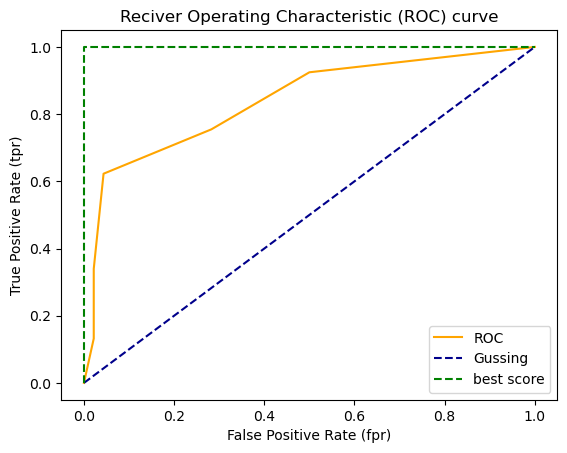

In [93]:
helpers.plot_roc_curve(knnc, X_test, y_test)

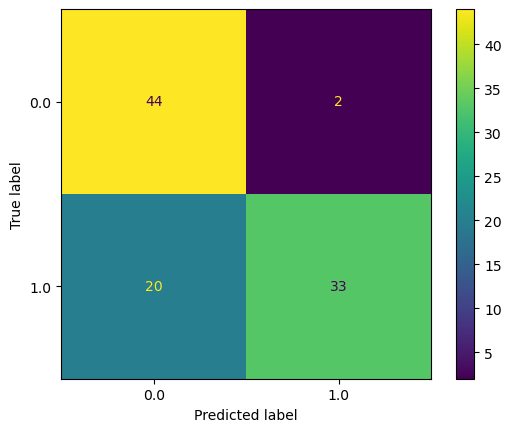

In [94]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_hat, y_true=y_test)

#### KNN + GridSearch

In [ ]:
knnc_with_gs = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}

knnc_with_gs = helpers.run_grid_search(
    knnc_with_gs, param_grid, X_train, y_train, 5, "KNN"
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

--- Grid Search for `KNN` ---
Best Hyper Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best Mean Log Loss (CV): 1.4323


In [104]:
y_hat = knnc_with_gs.predict(X_test)
knnc_with_gs_result = helpers.evaluate_classification_model(
    y_pred=y_hat, y_test=y_test, model_name="random forest"
)

              precision    recall  f1-score   support

         0.0       0.72      0.91      0.81        46
         1.0       0.90      0.70      0.79        53

    accuracy                           0.80        99
   macro avg       0.81      0.81      0.80        99
weighted avg       0.82      0.80      0.80        99



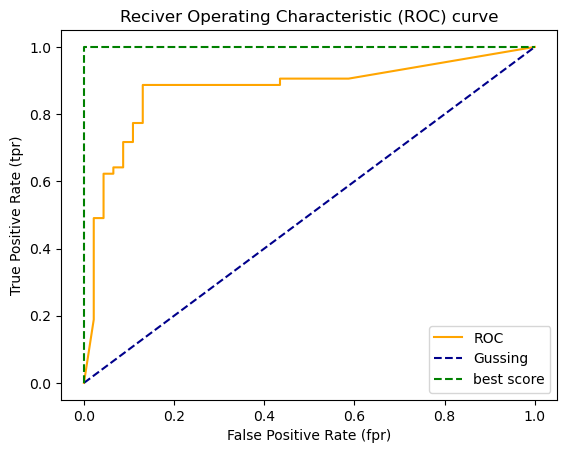

In [105]:
helpers.plot_roc_curve(knnc_with_gs, X_test, y_test)

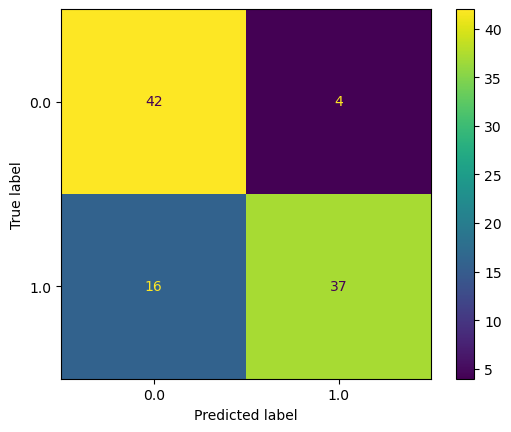

In [106]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_hat, y_true=y_test)

## Evaluation

### Chosing best model by `f1` metric

In [107]:
metric = "f1_score"
best_model_name = helpers.find_best_model(
    models_result=[
        svc_result,
        svc_with_gs_result,
        lr_result,
        lr_with_gs_result,
        rfc_result,
        rfc_with_gs_result,
        knnc_result,
        knnc_with_gs_result,
    ],
    metric=metric,
).model_name
print(f"best model is `{best_model_name}` by `{metric}` metric")

best model is `svc_with_gs` by `f1_score` metric


### Check models over/under fit by accuracy metric

In [ ]:
def check_model_over_under_fit(model, X_train, X_test, y_train, y_test):
    y_hat_train = model.predict(X_train)
    y_hat_test = model.predict(X_test)

    train_acc = accuracy_score(y_pred=y_hat_train, y_true=y_train) * 100
    test_acc = accuracy_score(y_pred=y_hat_test, y_true=y_test) * 100

    print(f"Accuracy on training data: {train_acc:.2f}, ", end="")
    print(f"Accuracy on test data: {test_acc:.2f}.")

In [48]:
check_model_over_under_fit(svc, X_train, X_test, y_train, y_test)
check_model_over_under_fit(rfc, X_train, X_test, y_train, y_test)
check_model_over_under_fit(lr, X_train, X_test, y_train, y_test)
check_model_over_under_fit(knnc, X_train, X_test, y_train, y_test)

Accuracy on training data: 99.13, Accuracy on test data: 88.89.
Accuracy on training data: 100.00, Accuracy on test data: 83.84.
Accuracy on training data: 66.23, Accuracy on test data: 60.61.
Accuracy on training data: 100.00, Accuracy on test data: 78.79.


### Using cross validation with 5-fold 

I want to do a cross validation with cv equal to 5:

In [55]:
helpers.calculate_cross_validation(
    svc, X_resampled, y_resampled, random_state=SEED, cv=5, scoring="f1"
)

(array([0.86956522, 0.89855072, 0.82352941, 0.86153846, 0.88235294]),
 np.float64(0.8671073513017247),
 np.float64(0.02512848658624329),
 {'Fold_1_f1': np.float64(0.8695652173913043),
  'Fold_2_f1': np.float64(0.8985507246376812),
  'Fold_3_f1': np.float64(0.8235294117647058),
  'Fold_4_f1': np.float64(0.8615384615384616),
  'Fold_5_f1': np.float64(0.8823529411764706),
  'Mean_Score': np.float64(0.8671073513017247),
  'Std_Score': np.float64(0.02512848658624329)})

In [50]:
helpers.calculate_cross_validation(
    rfc, X_resampled, y_resampled, random_state=SEED, cv=5, scoring="f1"
)

(array([0.875     , 0.84057971, 0.77142857, 0.86567164, 0.82191781]),
 np.float64(0.8349195463167444),
 np.float64(0.03683563677713816),
 {'Fold_1_f1': np.float64(0.875),
  'Fold_2_f1': np.float64(0.8405797101449275),
  'Fold_3_f1': np.float64(0.7714285714285715),
  'Fold_4_f1': np.float64(0.8656716417910447),
  'Fold_5_f1': np.float64(0.821917808219178),
  'Mean_Score': np.float64(0.8349195463167444),
  'Std_Score': np.float64(0.03683563677713816)})

In [51]:
helpers.calculate_cross_validation(
    lr, X_resampled, y_resampled, random_state=SEED, cv=5, scoring="f1"
)

(array([0.72463768, 0.5625    , 0.63492063, 0.6875    , 0.65714286]),
 np.float64(0.6533402346445825),
 np.float64(0.054508541112033036),
 {'Fold_1_f1': np.float64(0.7246376811594203),
  'Fold_2_f1': np.float64(0.5625),
  'Fold_3_f1': np.float64(0.6349206349206349),
  'Fold_4_f1': np.float64(0.6875),
  'Fold_5_f1': np.float64(0.6571428571428571),
  'Mean_Score': np.float64(0.6533402346445825),
  'Std_Score': np.float64(0.054508541112033036)})

In [52]:
helpers.calculate_cross_validation(
    knnc, X_resampled, y_resampled, random_state=SEED, cv=5, scoring="f1"
)

(array([0.77192982, 0.75      , 0.64150943, 0.76363636, 0.77966102]),
 np.float64(0.7413473278218368),
 np.float64(0.05087730886171068),
 {'Fold_1_f1': np.float64(0.7719298245614035),
  'Fold_2_f1': np.float64(0.75),
  'Fold_3_f1': np.float64(0.6415094339622641),
  'Fold_4_f1': np.float64(0.7636363636363637),
  'Fold_5_f1': np.float64(0.7796610169491526),
  'Mean_Score': np.float64(0.7413473278218368),
  'Std_Score': np.float64(0.05087730886171068)})

## Setup the pipeline

We did some preprocess step + we chosed a model for this task. Now it is time to combine all of these in a single pipeline.

In [1]:
from sklearn.pipeline import Pipeline